In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [3]:
df["Machine failure"].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [4]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

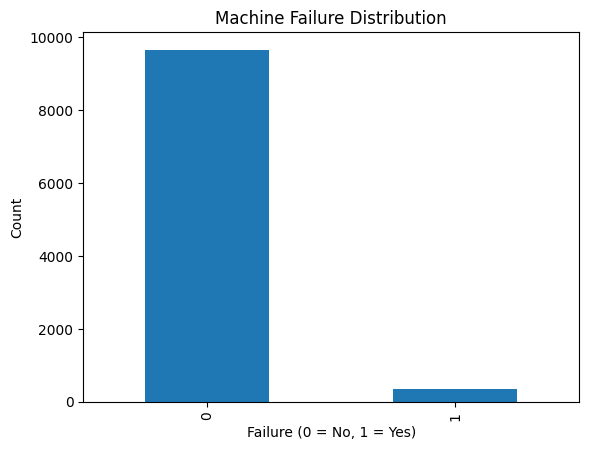

In [5]:
import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

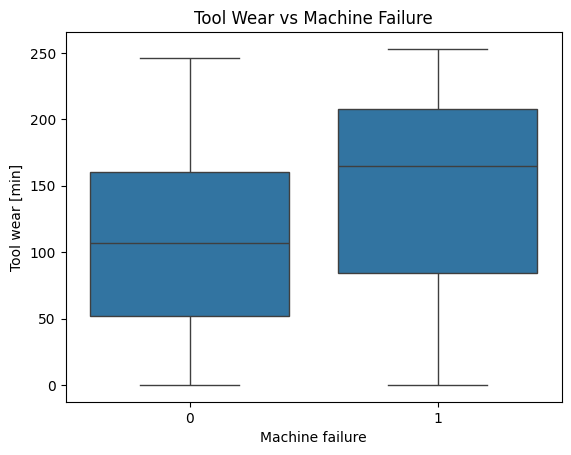

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)
plt.title("Tool Wear vs Machine Failure")
plt.show()

In [7]:
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]

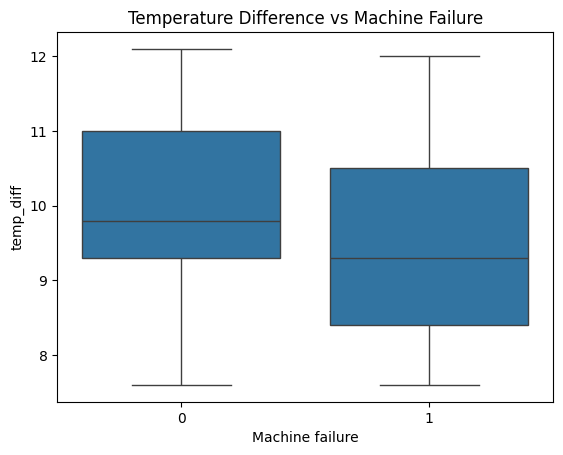

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Machine failure", y="temp_diff", data=df)
plt.title("Temperature Difference vs Machine Failure")
plt.show()

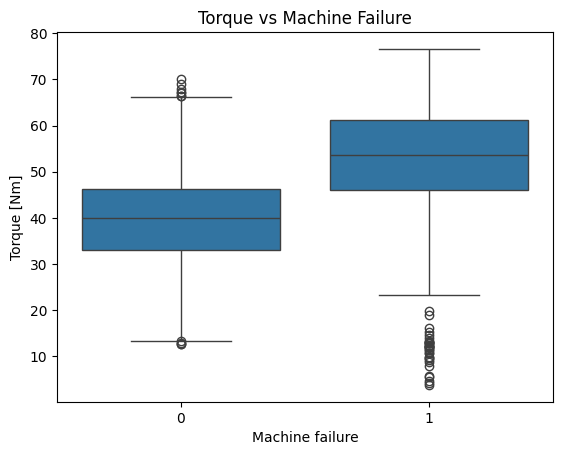

In [9]:
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)
plt.title("Torque vs Machine Failure")
plt.show()


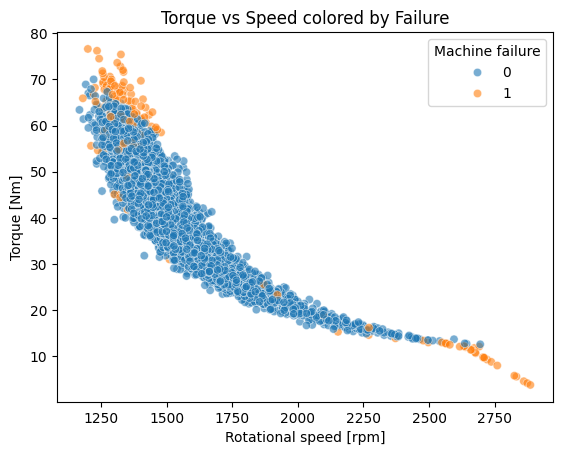

In [10]:
sns.scatterplot(
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    data=df,
    alpha=0.6
)

plt.title("Torque vs Speed colored by Failure")
plt.show()

In [11]:
df = df.drop(columns=["UDI", "Product ID"])

In [12]:
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

In [13]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]